# Lecture 18 - Exercise - The Ia Supernova dataset part II

In [1]:
#-------------------------------------------------------------------------
# importing libraries and setting up nice plots
#-------------------------------------------------------------------------

import os
import corner
import emcee
import numpy                        as np
import matplotlib.pyplot            as plt
import matplotlib                   as mpl
from   matplotlib                   import rc
from   mycolorpy                    import colorlist as mcp
from   numpy.random                 import default_rng
from   sys                          import stdout
from   scipy                        import stats, integrate, special
from   astroML                      import stats as astroMLstats
from   astroML.datasets             import generate_mu_z
from   astroML.linear_model         import PolynomialRegression, BasisFunctionRegression, NadarayaWatson
from   astropy.visualization.hist   import hist  as fancyhist
from   astropy.cosmology            import Planck15, LambdaCDM
from   sklearn.neighbors            import KernelDensity
from   sklearn.manifold             import Isomap, TSNE
from   sklearn.cluster              import KMeans
from   sklearn.neighbors            import KNeighborsClassifier
from   sklearn.metrics              import confusion_matrix, accuracy_score
from   sklearn.model_selection      import train_test_split, learning_curve, GridSearchCV, cross_val_predict
from   sklearn.mixture              import GaussianMixture
from   sklearn.decomposition        import PCA, NMF, FastICA
# from   sklearn.linear_model         import LogisticRegression, LinearRegression

#-------------------------------------------------------------------------

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif" : ["Times New Roman"],
	"font.size"  : 9,
    "figure.dpi" : 300
    })
plt.rc('text.latex', preamble=r'\usepackage{amssymb}')

current_pwd = os.getcwd()
print(current_pwd)

#-------------------------------------------------------------------------

WARNING (theano.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (theano.configdefaults): g++ not detected ! Theano will be unable to execute optimized C-implementations (for both CPU and GPU) and will default to Python implementations. Performance will be severely degraded. To remove this warning, set Theano flags cxx to an empty string.
WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.


d:\Documents\University\Magistrale\Statistics\GitHub\working


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\astropy\cosmology\flrw.py:1280: RuntimeWarning: divide by zero encountered in log10
  val = 5. * np.log10(abs(self.luminosity_distance(z).value)) + 25.0


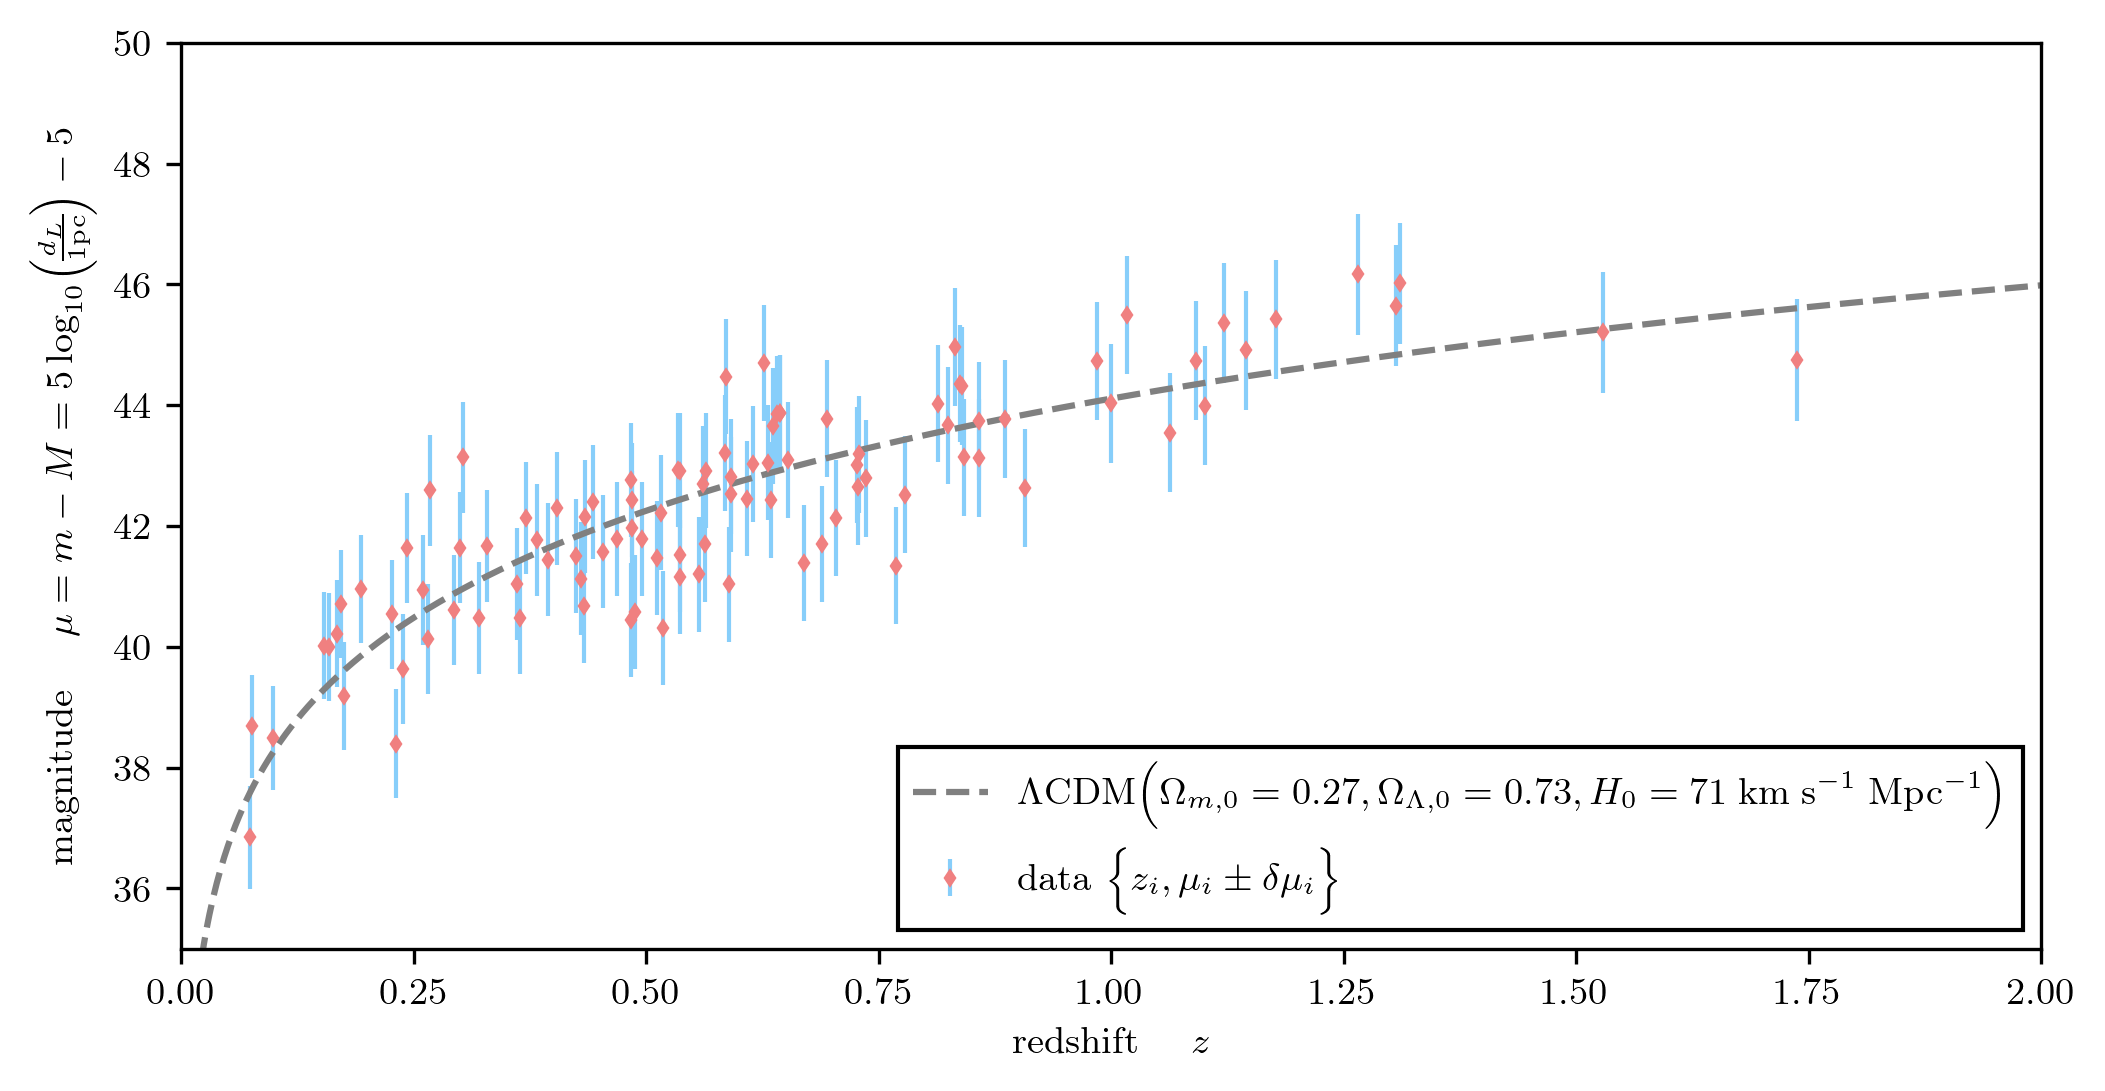

In [15]:
#-------------------------------------------------------------------------
# Generate data and visualize it
#-------------------------------------------------------------------------

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

fig , ax = plt.subplots(figsize=(8,4))

plt.errorbar(z_sample, mu_sample, dmu, color='lightcoral', marker='d', markersize=2, ecolor='lightskyblue', ls='', lw=1, label=r'data $\big\{z_i , \mu_i \pm \delta \mu_i\big\}$')
plt.xlabel(r"redshift $\quad z$")
plt.ylabel(r"magnitude $\quad \mu = m - M = 5 \log_{10}\!\left(\!\frac{d_L}{\rm 1 pc}\!\right) - 5$")
plt.xlim(0,2)
plt.ylim(35,50)

#-------------------------------------------------------------------------
# I'm not supposed to know this but I'm not using this info, 
# just plotting it for comparison
#-------------------------------------------------------------------------

cosmo = LambdaCDM(H0=71, Om0=0.27, Ode0=1-0.27)

z_grid = np.linspace(0,2,1000)
mu_true = cosmo.distmod(z_grid)
label_LCDM = r'$\Lambda$CDM$\big(\Omega_{m,0} =0.27 , \Omega_{\Lambda,0} = 0.73, H_0 = 71 \;\textup{km} \; \textup{s}^{-1} \; \textup{Mpc}^{-1}\big)$'
plt.plot(z_grid, mu_true, ls='--', color='gray', label=label_LCDM)

#-------------------------------------------------------------------------

ax.legend(loc=4, frameon=True, framealpha=1, fancybox=False, edgecolor='black' )


#-------------------------------------------------------------------------

The FRW metric is:

$$
g_{\mu\nu} = 
- c^2 \textup{d}t^2
+ a^2(t) \left( 
    \frac{1}{1 - kr^2} \; \textup{d}r^2 
    + r^2 \; \textup{d}\vartheta^2 
    + r^2 \sin^2\!\vartheta \; \textup{d} \varphi^2 
\right)
$$

Computing the Christoffel coefficients, it's easy to find that:

$$
\Gamma^0_{ij} = \frac{1}{c} \frac{\dot{a}(t)}{a(t)} g_{ij}
\quad ; \quad 
\Gamma^0_{00} = 0 
$$

So that the 0-component of the geodesic equation is:

$$
\frac{\textup{d}^2 x^0}{\textup{d}\tau^2} 
= - \Gamma^0_{\mu\nu} \frac{\textup{d} x^\mu}{\textup{d}\tau} \frac{\textup{d} x^\nu}{\textup{d}\tau} 
= 0 - \frac{1}{c} \frac{\dot{a}(t)}{a(t)} g_{ij} \frac{\textup{d} x^i}{\textup{d}\tau} \frac{\textup{d} x^j}{\textup{d}\tau}
= - \frac{\dot{a}(t)}{a(t)} \frac{| {\bm u}(t) |^2}{c} 
$$

But note also that:

$$
\frac{\textup{d}^2 x^0}{\textup{d}\tau^2} 
= \frac{\textup{d} u^0}{\textup{d} \tau} 
= \frac{\textup{d} t}{\textup{d} \tau} \frac{\textup{d} u^0}{\textup{d} t} 
= \gamma \frac{\textup{d} }{\textup{d} t} \sqrt{c^2 - |{\bm u}(t)|^2  }
= \gamma c \frac{\textup{d} }{\textup{d} t} \sqrt{ 1-\frac{|{\bm u}(t)|^2}{c^2} }
= \gamma c \frac{-2\dfrac{|{\bm u}(t)|}{c^2}}{2 \sqrt{ 1 - \dfrac{|{\bm u}(t)|^2}{c^2} }} \frac{\textup{d}|{\bm u}(t)|}{\textup{d} t} 
= -\gamma^2 \frac{|{\bm u}(t)|}{c} \frac{\textup{d}|{\bm u}(t)|}{\textup{d} t} 
$$

So that:

$$
-\gamma^2 \frac{|{\bm u}(t)|}{c} \frac{\textup{d}|{\bm u}(t)|}{\textup{d} t}  
= - \frac{\dot{a}(t)}{a(t)} \frac{| {\bm u}(t) |^2}{c} 
\quad \iff \quad
\frac{\textup{d}|{\bm u}(t)|}{\textup{d} t}
= \frac{\dot{a}(t)}{a(t)} \gamma^2 \, |{\bm u}(t)|
$$

Which leads to the reason why these are called comoving coordinates:

$$
{\rm if }\; |{\bm u}(t=0)|=0 \implies |{\bm u}(t)|=0 \;\,\forall\,t
$$

Imagine then two objects at $(t_0, r_1, \vartheta_0, \varphi_0 )$ and $(t_0, r_2, \vartheta_0, \varphi_0 )$. Then, their coordinate distance at $t_0$ is $r=r_2 - r_1$, and if their relative coordinate velocity is 0, their coordinate distance for all subsequent coordinate times $t$ will be the constant $r$. 

Instead, using the FRW metric, their physical proper distance is:

$$
\textup{d} s^2 
= \frac{a^2(t)}{1 - k r^2 } \; \textup{d} r^2 
\quad \implies \quad 
s(t) 
= a(t) \int_0^r \frac{\textup{d} r}{\sqrt{ 1  - kr^2 }}
= a(t) \, r 
\quad (\textup{if flat universe } k = 0)
$$

Consider now signals moving along the massless geodesic equation:

$$

\textup{d}s^2 = 0
\quad \iff \quad
c^2 \textup{d} t^2 
= \frac{a^2(t)}{1 - k r^2 } \; \textup{d} r^2 
\quad \iff \quad 
\int_{t_\textup{emiss}}^{t_\textup{obs}} 
\frac{c \,\textup{d}t}{a(t)}
= \int_0^r \frac{\textup{d} r}{\sqrt{ 1  - kr^2 }}
= \int_{t_\textup{emiss}+\delta t_\textup{emiss}}^{t_\textup{obs}+\delta t_\textup{obs}} 
\frac{c \,\textup{d}t}{a(t)}
$$

Then to first order:

$$
0 = \int_{t_\textup{emiss}+\delta t_\textup{emiss}}^{t_\textup{obs}+\delta t_\textup{obs}} 
\frac{c \,\textup{d}t}{a(t)}
- \int_{t_\textup{emiss}}^{t_\textup{obs}} 
\frac{c \,\textup{d}t}{a(t)}
\approx 
\frac{c \,\delta t_\textup{obs}}{a(t_\textup{obs})} 
- \frac{c \,\delta t_\textup{emiss}}{a(t_\textup{emiss})} 
\quad \iff \quad 
\delta t_\textup{obs} 
= \frac{a(t_\textup{obs})}{a(t_\textup{emiss})}
\delta t_\textup{emiss}
$$

Renaming $t_\textup{emiss} := t_s$ and $t_\textup{obs} = t_o$ then we define the redshift of a source:

$$ \boxed{
1 + z_s 
= \frac{a(t_o)}{a(t_s)} 
= \frac{ \textup{d} t_o }{ \textup{d} t_s } 
= \frac{ \nu_s }{ \nu_o } 
= \frac{ \textup{d} E_s }{ \textup{d} E_o } 
} $$

Then, the observed power of a source can be expressed in terms of its luminosity and the redshift as:

$$ \boxed{ 
\frac{ \textup{d} E_o }{ \textup{d} t_o }
= \frac{ \textup{d} E_s }{ \textup{d} t_s } 
\frac{ 1 }{ (1 + z_s)^2 }
= \frac{ L_s }{ (1 + z_s)^2 }
} $$

A detector measures the flux: power that spreads isotropically over a sphere of area: $\quad A_o = 4\pi a^2(t_o) r^2 $

$$ \boxed{
F_o 
= \frac{1}{A_o} \frac{ \textup{d} E_o }{ \textup{d} t_o } 
= \frac{ L_s }{ 4\pi \, a^2(t_o) \, r^2 \; (1 + z_s)^2 } 
=:  \frac{ L_s }{ 4\pi \, d_L^2(z_s) } 
} $$

Where we have finally defined the luminosity distance:

$$
d_L (z_s) = (1 + z_s) \, a(t_o) \, r
$$

We usually don't know $r$ though! So, Taylor expand as follows:

$$
\frac{1}{1+z_s} 
= \frac{a(t_s)}{a(t_o)}
= 1 
+ \frac{\dot{a}(t_o)}{a(t_o)} (t_s - t_o)
+ \frac{1}{2} \frac{\ddot{a}(t_o)}{a(t_o)} (t_s - t_o)^2 
+ ...
= 1 + H_0 (t_s - t_o) - \frac{1}{2} \frac{q_0}{H_0^2} (t_s - t_o)^2 +...
$$

And invert this $z_s(t_s - t_o)$ to find perturbatively $t_s(z_s)$. Then, remember we can compute $r$ with:

$$
\int_0^r \frac{\textup{d} r}{\sqrt{ 1  - kr^2 }}
= \int_{t_\textup{s}}^{t_\textup{o}} 
\frac{c \,\textup{d}t}{a(t)}
\quad 
\textup{insert here the expansion in terms of } t_s-t_o \textup{ and thus of } z_s 
$$

The result is the relation:

$$ \boxed{
\frac{H_0}{c} \, d_L(z_s) 
= z_s 
+ \frac{1}{2} \left( 1 + \frac{\ddot{a}(t_o)}{a(t_o)} \frac{1}{H_0^2} \right) z_s^2 
}
$$

Which to first order in $z_s$ is just the Hubble law. 

Note that we can differentiate the redshift definition:

$$
\frac{\textup{d}z}{\textup{d} t }
= \frac{\textup{d}}{\textup{d} t } \big( 1 + z(t) \big) 
= \frac{\textup{d}}{\textup{d} t } \frac{a(t_o)}{a(t)}
= - a(t_o) \frac{\dot{a}(t)}{a^2(t)}
= - \frac{a(t_o)}{a(t)} \, H\big(t(z)\big)
\quad \implies \quad
\frac{\textup{d} t}{a(t)}
= - \frac{1}{a(t_o) } \frac{\textup{d}z}{H(z)} 
$$

For a flat universe $k=0$ we can write:

$$
r = \int_0^r \frac{\textup{d} r}{\sqrt{ 1  - kr^2 }} \bigg|_{k=0}
= \int_{t_\textup{s}}^{t_\textup{o}} 
\frac{c \,\textup{d}t}{a(t)}
= - \frac{c}{a(t_o)} \int_{z_s}^0 \frac{\textup{d}z}{H(z)}
= \frac{c}{a(t_o)} \int_0^{z_s} \frac{\textup{d}z}{H(z)}
$$

So that finally we can write:

$$ \boxed{
d_L(z_s) 
= (1 + z_s) \, a(t_o) \, r
= (1 + z_s) \, c \int_0^{z_s} \frac{\textup{d}z}{H(z)}
} $$

Or equivalently taking the derivative with respect to the redshift:

$$ \boxed{
\frac{ \textup{d} }{ \textup{d} z} \left( \frac{d_L(z)}{1+z} \right)
= \frac{c}{H(z)}
} $$

Astronomers define the magnitude of a source as:

$$
\mu(z_s) = 5 \log_{10} \left( \dfrac{d_L(z_s)}{10 \textup{ pc}} \right)
$$

We then need an explicit expression for $H(z)$ which is computed depending on the cosmological model. 

Typically, for a flat ($k=0$) Universe with non-zero cosmological constant $\Lambda$:

$$ \boxed{
H(z) = \dfrac{\dot{a}\big(t(z)\big)}{a\big(t(z)\big)} 
= H_0 \sqrt{ \Omega_{\Lambda,0} + \Omega_{\textup{M},0} \, (1+z)^3}
} $$

Then, the magnitude is:

$$
\mu(z_s) 
= 5 \log_{10} \left( \dfrac{d_L(z_s)}{10 \textup{ pc}} \right)
= 5 \log_{10} \left( 
    \dfrac{c}{10 \textup{ pc}} \, (1 + z_s) \, \int_0^{z_s} \dfrac{\textup{d}z}{H(z)} 
\right) 
= 5 \log_{10} \left( 
    \dfrac{c}{H_0 \, 10 \textup{ pc}} \, (1 + z_s) \, 
    \int_0^{z_s} \dfrac{\textup{d}z}{ \sqrt{ \Omega_{\Lambda,0} + \Omega_{\textup{M},0} \, (1+z)^3} } 
\right) 
$$

It is useful to re-write the constants as:

$$
\dfrac{c}{H_0} = \frac{3000 \textup{ Mpc}}{h_0} 
\implies
5 \log_{10} \left( \dfrac{c}{H_0 \, 10\textup{ pc}} \right)
= 5 \log_{10} \left( \frac{3 \cdot 10^8 \textup{ pc}}{10 \textup{ pc} } \right) - 5 \log_{10}\big(h_0 \big)
= 5 \log_{10} \big( 3 \cdot 10^7 \big) - 5 \log_{10}\big(h_0 \big)
= 5K - 5 \log_{10}\big(h_0 \big)
$$

And to note that the integral is an hypergeometric function:

$$
\int_0^{z} \dfrac{\textup{d}z'}{ \sqrt{ \Omega_{\Lambda,0} + \Omega_{\textup{M},0} \, (1+z')^3} } 
= \Bigg[ 
\frac{1}{\sqrt{\Omega_{\Lambda,0}}} 
\, (1 + z)
\phantom{0}_{2}F_{1} \left( \frac{1}{3};\frac{1}{2};\frac{4}{3};-\frac{\Omega_{\textup{M},0}}{\Omega_{\Lambda,0}} (1+z)^3 \right)
\Bigg]^z_0
% \, \sqrt{ \Omega_{\Lambda,0} + \Omega_{\textup{M},0} \, (1+z)^3} 
% \; \phantom{0}_{2}F_{1} \left( \frac{5}{6} ; 1 ; \frac{4}{3} ; - \frac{\Omega_{\textup{M},0}}{\Omega_{\Lambda,0}} (1+z)^3 \right)
$$

Our parametric model for the magnitude is then:

$$ \boxed{
\begin{array}{rcl}
    \frac{1}{5} \, \mu \big(z | h_0 , \Omega_{\Lambda,0} , \Omega_{\textup{M},0} \big) 
    \!\!&\!\!=\!\!&\!\!
    \log_{10} ( 1 + z ) - \log_{10} h_0 - \frac{1}{2}\log_{10} \Omega_{\Lambda,0} + \log_{10} \!\big( 3 \cdot 10^7 \big)
% \\ \\
%     \phantom{ \frac{1}{5} \, \mu \big(z | h_0 , \Omega_{\Lambda,0} , \Omega_{\textup{M},0} \big) } 
%     \!\!&\!\! + \!\!&\!\!
%     \frac{1}{2} \log_{10} \Big( \Omega_{\Lambda,0} + \Omega_{\textup{M},0} \, (1+z)^3 \Big)
\\ \\
    \phantom{ \frac{1}{5} \, \mu \big(z | h_0 , \Omega_{\Lambda,0} , \Omega_{\textup{M},0} \big) } 
    \!\!&\!\! + \!\!&\!\!
    \log_{10} \!\Bigg( \bigg[ 
        (1+z)
        \!\!\phantom{0}_{2}F_{1} \bigg( \frac{1}{3};\frac{1}{2};\frac{4}{3}; - \frac{\Omega_{\textup{M},0}}{\Omega_{\Lambda,0}} (1+z)^3 \bigg) \bigg]^z_0 \Bigg)\!
% \\ \\
% \phantom{ \frac{1}{5} \, \mu \big(z | h_0 , \Omega_{\Lambda,0} , \Omega_{\textup{M},0} \big) } 
% \!\!&\!\! - \!\!&\!\!
%     \log_{10} h_0 - \frac{1}{2}\log_{10} \Omega_{\Lambda,0} + K
\end{array} }
$$





# Recap of part I results

In [16]:
#-------------------------------------------------------------------------
# define the regressio models (polynomials of various orders)
#-------------------------------------------------------------------------

pol_degrees = range(1,6)
pol_regr = []
theta = []
mu_pred = []
for d in pol_degrees:
    pol_regr.append(PolynomialRegression(d))

[2, 5, 5, 3, 2, 4, 5, 4, 2, 2, 5, 5, 1, 2, 2, 2, 2, 2, 1, 2, 4, 2, 2, 2, 2, 2, 2, 4, 2, 2, 5, 1, 2, 2, 2, 4, 3, 2, 4, 2, 1, 2, 2, 5, 2, 4, 2, 4, 2, 2, 5, 4, 2, 5, 2, 2, 2, 2, 5, 2, 2, 4, 2, 2, 5, 1, 2, 2, 4, 4, 2, 2, 4, 5, 2, 4, 2, 2, 2, 3, 4, 2, 4, 3, 2, 5, 5, 4, 2, 2, 2, 4, 2, 4, 2, 2, 5, 5, 5, 3, 4, 2, 4, 2, 1, 1, 2, 2, 2, 4, 2, 2, 2, 2, 5, 2, 4, 2, 3, 2, 2, 5, 4, 2, 2, 5, 4, 1, 2, 2, 2, 2, 2, 2, 2, 1, 4, 1, 3, 2, 2, 1, 4, 2, 5, 4, 4, 5, 2, 5, 2, 5, 4, 2, 2, 2, 2, 5, 2, 2, 4, 2, 4, 2, 4, 2, 2, 2, 2, 4, 2, 2, 2, 3, 2, 5, 4, 4, 4, 5, 2, 4, 4, 4, 2, 4, 2, 2, 3, 5, 1, 5, 4, 1, 4, 2, 4, 2, 2, 5, 2, 5, 5, 2, 5, 2, 2, 2, 5, 5, 2, 4, 2, 4, 4, 2, 2, 2, 4, 2, 4, 2, 4, 5, 5, 2, 2, 2, 2, 4, 2, 2, 5, 2, 4, 2, 2, 4, 5, 2, 2, 5, 2, 5, 5, 5, 2, 4, 1, 2, 4, 5, 5, 4, 2, 2, 4, 2, 5, 4, 5, 2, 2, 4, 5, 2, 1, 4, 2, 4, 5, 4, 4, 4, 2, 2, 2, 1, 5, 3, 3, 5, 1, 4, 4, 2, 5, 2, 2, 2, 2, 1, 4, 2, 5, 5, 2, 2, 2, 2, 4, 5, 2, 2, 4, 2, 1, 1, 1, 2, 5, 1, 5, 2, 4, 5, 5, 4, 4, 4, 5, 2, 5, 2, 2, 2, 1, 2, 2, 2, 4, 3, 5, 

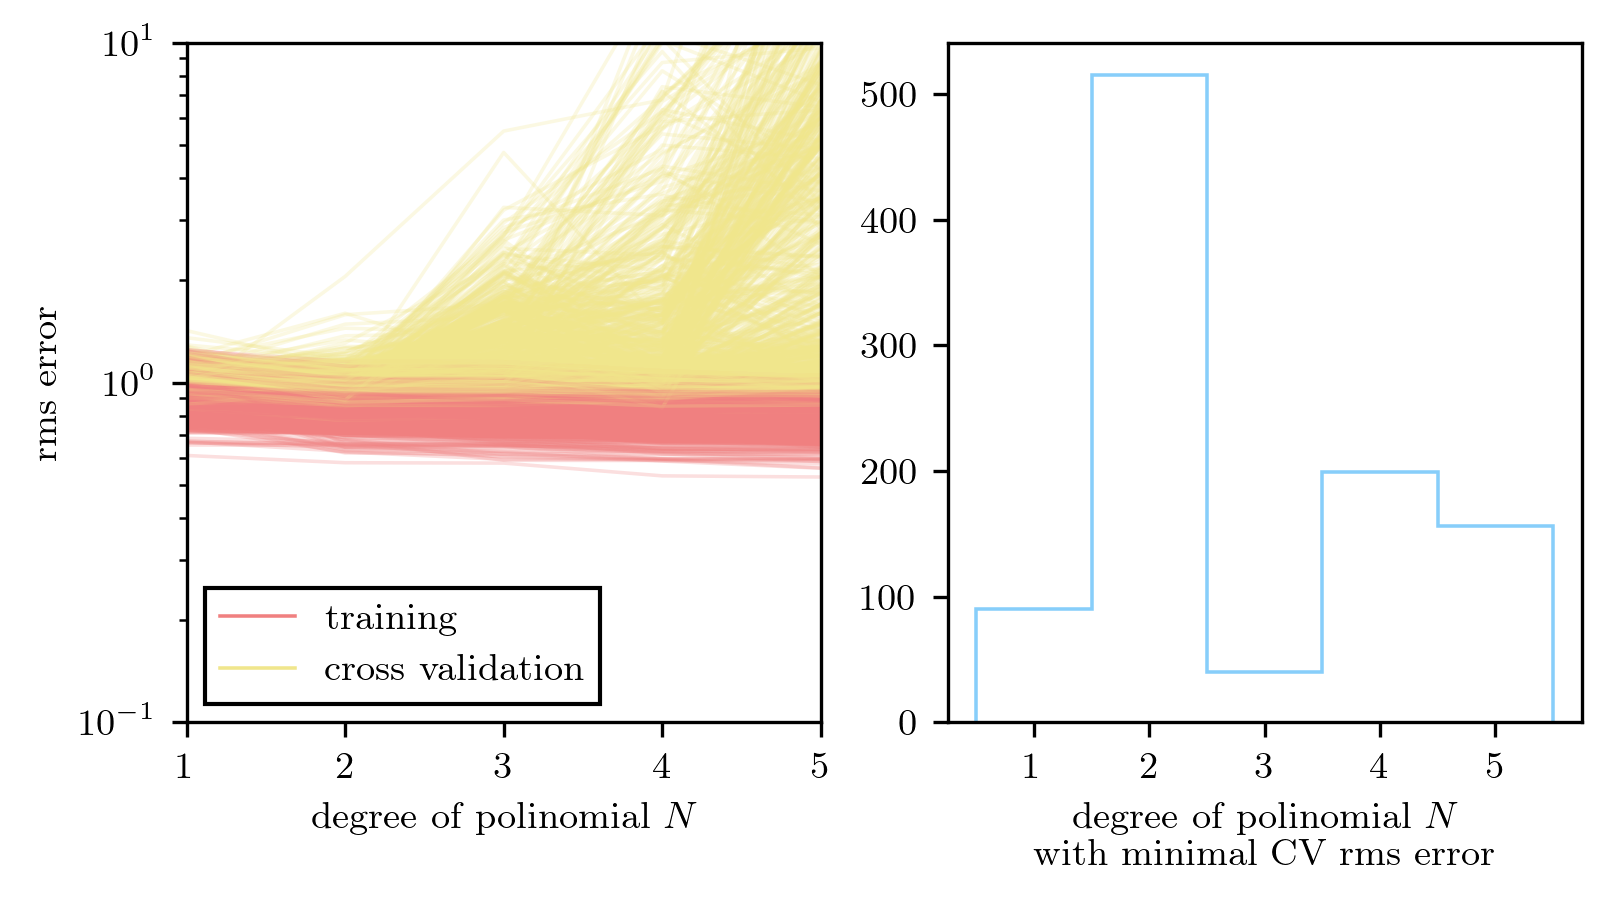

In [22]:
#-------------------------------------------------------------------------
# Now do the Cross Validation 1000 times to compute the best polynomial degree
# as the mode (most recurring result) and for this mode, average the best fits
#-------------------------------------------------------------------------

fig , ax = plt.subplots(1,2,figsize=(6,3))

ax[0].set_xlabel(r'degree of polinomial $N$')
ax[0].set_ylabel('rms error')
ax[0].set_xlim(1,5)
ax[0].set_yscale('log')
ax[0].set_ylim(1e-1,1e1)

ax[1].set_xticks(np.linspace(1,5,5))
ax[1].set_xlabel(r'degree of polinomial $N$'+'\nwith minimal CV rms error')

best_deg_CV_lots = []
best_theta_CV_lots = []
mu_grid_lots = []

ax[0].plot([], [], lw=0.85, color='lightcoral', label='training')
ax[0].plot([], [], lw=0.85, color='khaki', label='cross validation')

for j in range(1000):

    z_train, z_test, mu_train, mu_test, dmu_train, dmu_test = train_test_split(z_sample, mu_sample, dmu, test_size=0.65)

    N_train = len(z_train)
    N_test  = len(z_test)

    pol_degrees = range(1,6)
    pol_regr = []

    for d in pol_degrees:
        pol_regr.append(PolynomialRegression(d))

    training_err = np.zeros(len(pol_degrees))
    crossval_err = np.zeros(len(pol_degrees))

    theta_train = []
    mu_grid_train = []

    for i in range(5):

        pol_regr[i].fit(z_train[:,np.newaxis], mu_train, dmu_train)

        theta_i = pol_regr[i].coef_
        theta_train.append(theta_i)

        mu_grid_i = pol_regr[i].predict(z_grid[:,np.newaxis])
        mu_grid_train.append(mu_grid_i)

        mu_train_i = pol_regr[i].predict(z_train[:,np.newaxis])
        mu_test_i  = pol_regr[i].predict(z_test[:,np.newaxis])

        training_err[i] = np.sqrt( np.sum( (mu_train_i - mu_train)**2 / N_train) )
        crossval_err[i] = np.sqrt( np.sum( (mu_test_i  - mu_test)**2  / N_test) )
    
    ax[0].plot(pol_degrees, training_err, alpha=0.25, lw=0.85, color='lightcoral')
    ax[0].plot(pol_degrees, crossval_err, alpha=0.25, lw=0.85, color='khaki')

    best_deg = pol_degrees[np.argmin(crossval_err)]
    best_deg_CV_lots.append(best_deg)

    best_pol_regr = PolynomialRegression(best_deg)

    # train data only
    best_pol_regr.fit(z_train[:,np.newaxis], mu_train, dmu_train)

    best_theta_tr = best_pol_regr.coef_
    best_theta_CV_lots.append(best_theta_tr)
    
    mu_grid_tr = best_pol_regr.predict(z_grid[:,np.newaxis])
    mu_grid_lots.append(mu_grid_tr)

_ = fancyhist(best_deg_CV_lots, ax=ax[1], bins=np.linspace(0.5,5.5,6), histtype='step', density=False, color='lightskyblue', lw=0.85)

_ = ax[0].legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc=3)

print(best_deg_CV_lots)

best_deg_CV = stats.mode(best_deg_CV_lots).mode[0]     # weird syntax but ok

In [23]:
#-------------------------------------------------------------------------
# Organize results from multiple cross validations

print('The best degree for polynomial fitting is {:d}'.format(best_deg_CV))

best_deg_CV_lots = np.array(best_deg_CV_lots)
print(best_deg_CV_lots.shape)

best_theta_CV_lots = np.array(best_theta_CV_lots)
print(best_theta_CV_lots.shape)

mu_grid_lots = np.array(mu_grid_lots)
print(mu_grid_lots.shape)

#-------------------------------------------------------------------------
# select only the training-validation splits with N_polynomial_best=2

index = best_deg_CV_lots == best_deg_CV
# print(index)

N_best_degs = len(best_deg_CV_lots[index])
print('The number of fits we have done with {:d} is {:d}'.format(best_deg_CV, N_best_degs))

mu_grid_onlybest = np.copy(mu_grid_lots[index,:])
print(mu_grid_onlybest.shape)

mu_grid_onlybest_avg = np.average(mu_grid_onlybest, axis=0)
print(mu_grid_onlybest_avg.shape)

best_theta_onlybest = np.array(best_theta_CV_lots[index])
best_theta_onlybest_avg = np.average(best_theta_onlybest)

#-------------------------------------------------------------------------


The best degree for polynomial fitting is 2
(1000,)
(1000,)
(1000, 1000)
The number of fits we have done with 2 is 515
(515, 1000)
(1000,)


C:\Users\andre\AppData\Local\Temp\ipykernel_32296\3666412722.py:9: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  best_theta_CV_lots = np.array(best_theta_CV_lots)


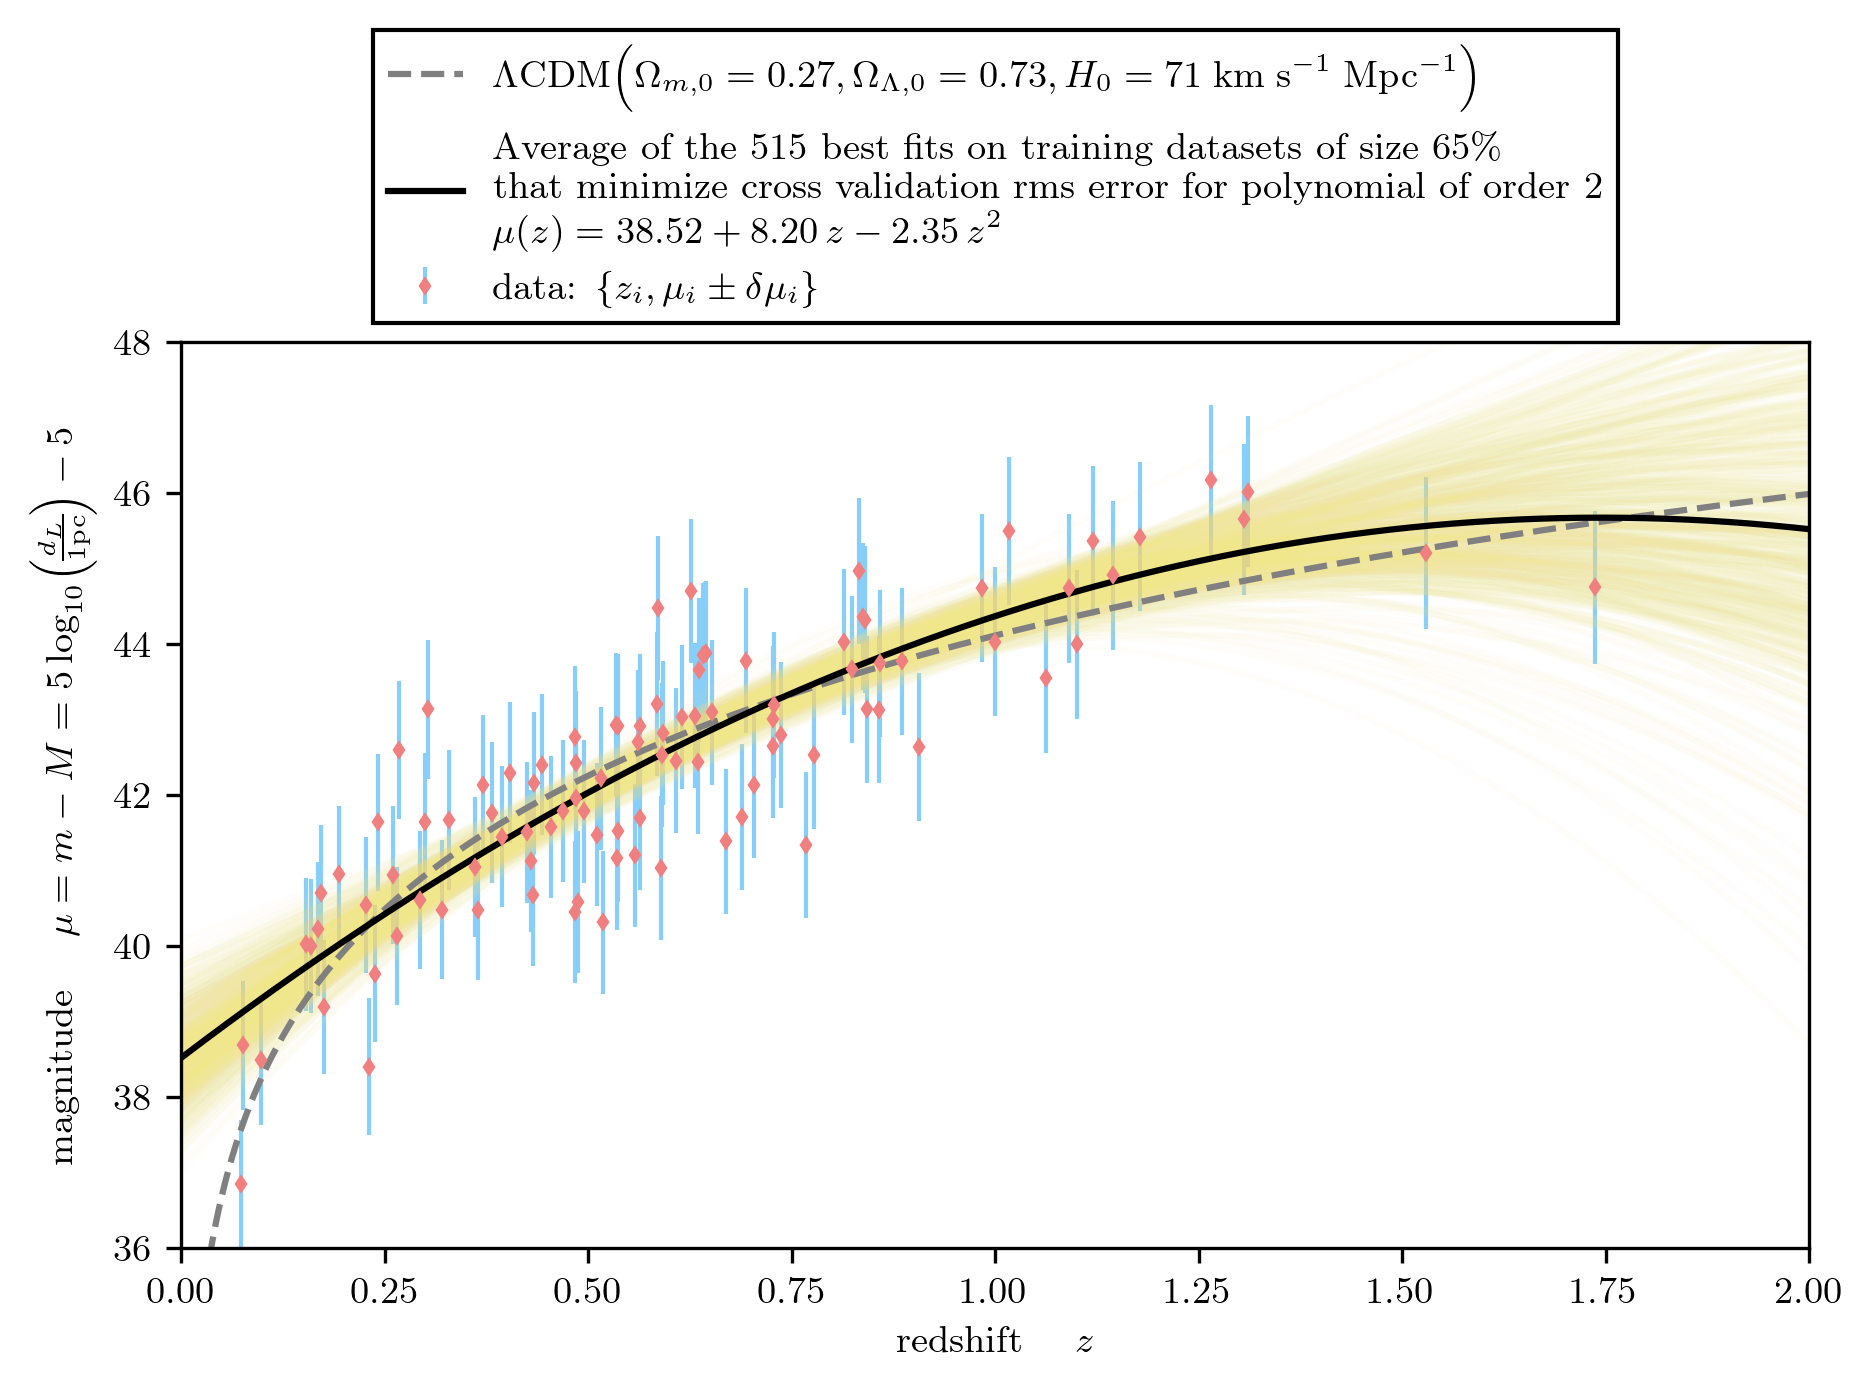

In [28]:
#-------------------------------------------------------------------------
# finally plot the best fit curve as average of the cross validated models
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(7,4))


ax.errorbar(z_sample, mu_sample, dmu, color='lightcoral', marker='d', markersize=2, ecolor='lightskyblue', ls='', lw=1, label='data: $\{z_i, \mu_i \pm \delta\mu_i\}$')

ax.set_xlabel(r"redshift $\quad z$")
ax.set_ylabel(r"magnitude $\quad \mu = m - M = 5 \log_{10}\!\left(\!\frac{d_L}{\rm 1 pc}\!\right) - 5$")
ax.set_xlim(0,2)
ax.set_ylim(36,48)

# ax.plot(z_grid, mu_grid_CV, color=color1ist[best_deg_CV-1], label=best_label)  
for i in range(N_best_degs):
    ax.plot(z_grid, mu_grid_onlybest[i,:], color='khaki', alpha=0.05) 

labellina = 'Average of the {:d} best fits on training datasets of size 65\%\n'.format(N_best_degs)
labellina += 'that minimize cross validation rms error for polynomial of order {:d}\n'.format(best_deg_CV)
labellina += '$\mu(z) = {:.2f}'.format(best_theta_onlybest_avg[0])
if best_theta_onlybest_avg[1] >= 0:
    labellina += '+ {:.2f} \, z '.format(best_theta_onlybest_avg[1])
else:
    labellina += '{:.2f} \, z '.format(best_theta_onlybest_avg[1])
if best_theta_onlybest_avg[2] >= 0:
    labellina += '+ {:.2f} \, z^2 $'.format(best_theta_onlybest_avg[2])
else: 
    labellina += '{:.2f} \, z^2 $'.format(best_theta_onlybest_avg[2])

label_LCDM = r'$\Lambda$CDM$\big(\Omega_{m,0} =0.27 , \Omega_{\Lambda,0} = 0.73, H_0 = 71 \;\textup{km} \; \textup{s}^{-1} \; \textup{Mpc}^{-1}\big)$'
ax.plot(z_grid, mu_true, ls='--', color='gray', label=label_LCDM)

ax.plot(z_grid, mu_grid_onlybest_avg, color='black', label=labellina) 



_ = ax.legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc='lower center',bbox_to_anchor=(0.5,1.0)) #,bbox_to_anchor=(0.75,0))

#-------------------------------------------------------------------------